# Flux systematic universes — integrated rate (side-by-side)

Horizontally tiled universe histograms for each Flux knob and the combined
(per-universe product) Flux total on the **integrated** event rate, matching
``systematics.ipynb``. Each panel overlays the universe mean in dotted red
("Mean Value").


In [1]:
%load_ext autoreload
%autoreload 2


In [10]:
from os import path, makedirs
from datetime import datetime
from pathlib import Path
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from pandas.errors import PerformanceWarning
from tqdm import tqdm

import sys
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana')

from pyanalib.variable_calculator import get_cc1p0pi_tki
from pyanalib.pandas_helpers import pad_column_name

from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
from analysis_village.numucc_1p0pi.categories import get_topo_category
from analysis_village.numucc_1p0pi.selection_framework import multicol_resolve_column_key
from analysis_village.numucc_1p0pi.dataset_locations import MULTISIM_SYST_GLOBS_FINAL
from analysis_village.numucc_1p0pi.syst_multisim_common import (
    drop_bad_flux_knob_weights,
    flux_mc_knob_names,
)

from pyanalib.split_df_helpers_new import dfs_from_dir

warnings.filterwarnings('ignore', category=PerformanceWarning)
plt.style.use('presentation.mplstyle')


def _ts():
    return datetime.now().strftime('%H:%M:%S')


def _log(msg):
    print(f'[{_ts()}] {msg}', flush=True)


In [3]:
SYST_NAME = 'Flux'
n_univ = 100
cov_type = 'rate'
bkgd_subtract = True
VERBOSE_UNIV_LOOP = False

var_config = VariableConfig.all_events()  # integrated single-bin rate

today_str = datetime.now().strftime('%Y%m%d')
OUT_DIR = path.join(save_fig_base_dir, f'flux-asymmetry-{today_str}')
makedirs(OUT_DIR, exist_ok=True)
SAVE_FIG = path.join(OUT_DIR, 'flux-integrated-universes-side-by-side')
_log('output dir: ' + OUT_DIR)


[15:07:53] output dir: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/flux-asymmetry-20260519


In [4]:
def multisim_search_dir(syst_name: str) -> str:
    if syst_name not in MULTISIM_SYST_GLOBS_FINAL:
        raise KeyError(f'no glob for {syst_name!r}; edit MULTISIM_SYST_GLOBS_FINAL')
    return str(Path(MULTISIM_SYST_GLOBS_FINAL[syst_name]).parent)


dirname = multisim_search_dir(SYST_NAME)
_log(f'loading {SYST_NAME} MC from {dirname} ...')
t_load = time.time()
dfs = dfs_from_dir(
    search_dir=dirname,
    filename_str='sel_mup',
    keys2load=['hdr', 'evt'],
    n_max_concat=999,
)
if 'evt' not in dfs:
    raise RuntimeError(f'no evt table for {SYST_NAME} under {dirname}')
evtdf_raw = dfs['evt']
_log(f'  {len(evtdf_raw):,} rows in {time.time() - t_load:.1f}s')


[15:07:53] loading Flux MC from /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_155745__sel_mup-wgts_flux/merged_perTPC ...
Found 15 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_155745__sel_mup-wgts_flux/merged_perTPC/2026_05_11_155745__sel_mup-wgts_flux_merged_0000.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_155745__sel_mup-wgts_flux/merged_perTPC/2026_05_11_155745__sel_mup-wgts_flux_merged_0001.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_155745__sel_mup-wgts_flux/merged_perTPC/2026_05_11_155745__sel_mup-wgts_flux_merged_0002.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_155745__sel_mup-wgts_flux/merged_perTPC/2026_05_11_155745__sel_mup-wgts_flux_merged_0003.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_155745__sel_mup-wgts_flux/merged_perTPC/2026_05_11_155745__sel_mup-wgts_flux_merged_0004.df', '/pnfs/sbnd/scratch/users/munjung/cafp

100%|██████████| 15/15 [00:59<00:00,  3.97s/it]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
[15:08:59]   74,249 rows in 65.6s


In [5]:
def evt_df_fixed(df):
    slc_mudf = df.mu.pfp.trk
    slc_pdf = df.p.pfp.trk
    tki_reco = get_cc1p0pi_tki(
        slc_mudf,
        slc_pdf,
        pad_column_name(('P', 'p_muon'), slc_mudf),
        pad_column_name(('P', 'p_proton'), slc_pdf),
    )
    df['del_Tp_x'] = tki_reco['del_Tp_x']
    df['del_Tp_y'] = tki_reco['del_Tp_y']

    mc_mudf = df.mu.pfp.trk.truth.p
    mc_pdf = df.p.pfp.trk.truth.p
    tki_mc = get_cc1p0pi_tki(
        mc_mudf,
        mc_pdf,
        pad_column_name(('totp',), mc_mudf),
        pad_column_name(('totp',), mc_pdf),
    )
    df['mc_del_Tp_x'] = tki_mc['del_Tp_x']
    df['mc_del_Tp_y'] = tki_mc['del_Tp_y']
    df[('mc', 'del_Tp_x')] = tki_mc['del_Tp_x']
    df[('mc', 'del_Tp_y')] = tki_mc['del_Tp_y']

    n_before = len(df)
    df = df[np.abs(df.slc.vertex.x) > 10]
    if 'topo_categ' not in df.columns:
        df = df.copy()
        df.loc[:, 'topo_categ'] = get_topo_category(df)
    return df, n_before


_log('running evt_df_fixed ...')
mc_evt_df, n_before = evt_df_fixed(evtdf_raw)
_log(f'  {len(mc_evt_df):,} events after FV cut ({n_before:,} before)')

knobs = flux_mc_knob_names('all')
_log(f'{len(knobs)} Flux knobs: {knobs[0]!r} ... {knobs[-1]!r}')
mc_evt_df = drop_bad_flux_knob_weights(mc_evt_df, knobs=knobs, n_univ=n_univ)
_log(f'  {len(mc_evt_df):,} events after weight cleaning')


[15:08:59] running evt_df_fixed ...


/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


[15:09:02]   74,249 events after FV cut (74,249 before)
[15:09:02] 13 Flux knobs: 'expskin_Flux' ... 'piplus_Flux'
[15:09:02]   74,249 events after weight cleaning


In [25]:
def flux_knob_display_label(knob_name):
    """Legend labels from ``systematics-summary.ipynb`` (BNB flux multisim keys)."""
    kn = str(knob_name)
    base = kn[:-5] if kn.endswith('_Flux') else kn
    labels = {
        'expskin': 'Exp.\nskin',
        'horncurrent': 'Horn\ncurrent',
        'kminus': r'$K^-$',
        'kplus': r'$K^+$',
        'kzero': r'$K^0$',
        'piminus': r'$\pi^-$',
        'piplus': r'$\pi^+$',
        'pioninexsec': r'$\pi$ inel. $\sigma$',
        'pionqexsec': r'$\pi$ QE $\sigma$',
        'piontotxsec': r'$\pi$ total $\sigma$',
        'nucleoninexsec': r'N inel. $\sigma$',
        'nucleonqexsec': r'N QE $\sigma$',
        'nucleontotxsec': r'N total $\sigma$',
    }
    return labels.get(base, base.replace('_', ' '))


def inject_multiplied_mc_knob_weights(df, knobs, bundled_tag='Flux', n_univ=100, verbose=False):
    """Product of per-knob weights at each universe index (``systematics.ipynb``)."""
    if verbose:
        _log(f'inject multiplied weights ({bundled_tag}): {len(knobs)} knobs x {n_univ} universes')
    df = df.copy()
    for uidx in tqdm(range(int(n_univ)), desc=f'inject {bundled_tag} product', disable=not verbose):
        w = np.ones(len(df), dtype=float)
        missing = False
        for knob in knobs:
            key = multicol_resolve_column_key(df, ('mc', knob, f'univ_{uidx}'))
            if key is None:
                missing = True
                break
            wi = np.asarray(df.loc[:, key], dtype=float)
            wi = np.nan_to_num(wi, nan=1.0, posinf=1.0, neginf=1.0)
            w *= wi
        if missing:
            continue
        col = ('mc', bundled_tag, f'univ_{uidx}', '', '', '', '')
        df.loc[:, col] = w
    return df


def get_univ_rates_integrated(evtdf, syst_name, verbose=False):
    univ, cv = get_univ_rates(
        cov_type,
        evtdf=evtdf,
        nudf=None,
        bkgd_subtract=bkgd_subtract,
        var_config=var_config,
        syst_name=syst_name,
        n_univ=n_univ,
        verbose=verbose,
    )
    return np.asarray(univ, dtype=float), np.asarray(cv, dtype=float)


In [26]:
panel_specs = []  # list of (label, univ, cv)

for iknob, knob in enumerate(tqdm(knobs, desc='Flux knobs (integrated)')):
    _log(f'knob [{iknob + 1}/{len(knobs)}] {knob}')
    univ, cv = get_univ_rates_integrated(mc_evt_df, ('mc', knob), verbose=VERBOSE_UNIV_LOOP)
    panel_specs.append((flux_knob_display_label(knob), univ, cv))

_log('combined Flux (multiplied per-universe weights) ...')
df_tot = inject_multiplied_mc_knob_weights(mc_evt_df, knobs, bundled_tag=SYST_NAME, n_univ=n_univ)
univ_tot, cv_tot = get_univ_rates_integrated(df_tot, ('mc', SYST_NAME), verbose=VERBOSE_UNIV_LOOP)
panel_specs.append(('Flux (total)', univ_tot, cv_tot))

_log(f'computed {len(panel_specs)} panels')


Flux knobs (integrated):   0%|          | 0/13 [00:00<?, ?it/s]

[15:27:29] knob [1/13] expskin_Flux


Flux knobs (integrated):   8%|▊         | 1/13 [00:08<01:39,  8.26s/it]

[15:27:38] knob [2/13] horncurrent_Flux


Flux knobs (integrated):  15%|█▌        | 2/13 [00:16<01:31,  8.35s/it]

...

Flux knobs (integrated):  92%|█████████▏| 12/13 [01:38<00:08,  8.20s/it]

[15:29:08] knob [13/13] piplus_Flux


Flux knobs (integrated): 100%|██████████| 13/13 [01:47<00:00,  8.24s/it]

[15:29:16] combined Flux (multiplied per-universe weights) ...


[15:29:25] computed 14 panels


In [27]:
def plot_univ_hists_on_ax(
    ax,
    univ_events,
    cv_events,
    var_config,
    title='',
    show_legend=False,
):
    """Universe histograms on one axes (``plot_univ_hists`` style) + mean overlay."""
    univ_events = np.asarray(univ_events, dtype=float)
    cv_events = np.asarray(cv_events, dtype=float)
    n_univ = univ_events.shape[0]
    mean_events = np.mean(univ_events, axis=0)

    if n_univ > 10:
        colors = ['#FDE725FF', '#1F968BFF', '#440154FF']
        sorted_univs = np.sort(univ_events, axis=0)
        n_68 = int(0.68 * n_univ)
        start_68 = (n_univ - n_68) // 2
        end_68 = start_68 + n_68
        n_95 = int(0.95 * n_univ)
        start_95 = (n_univ - n_95) // 2
        end_95 = start_95 + n_95
        segs = [
            (range(start_68, end_68), colors[0], 'Universe (68%)', False),
            (range(start_95, end_95), colors[1], 'Universe (95%)', True),
            (
                (i for i in range(n_univ) if i not in range(start_95, end_95)),
                colors[2],
                'Universe (100%)',
                False,
            ),
        ]
        plotted = set()
        for r, color, label, skip_68 in segs:
            for i in r:
                if skip_68 and i in range(start_68, end_68):
                    continue
                show_label = label if label not in plotted else None
                ax.hist(
                    var_config.bin_centers,
                    bins=var_config.bins,
                    weights=sorted_univs[i],
                    histtype='step',
                    color=color,
                    alpha=0.7,
                    label=show_label,
                )
                plotted.add(label)
    else:
        for i in range(n_univ):
            show_label = 'Universe' if i == 0 else None
            ax.hist(
                var_config.bin_centers,
                bins=var_config.bins,
                weights=univ_events[i],
                histtype='step',
                color='gray',
                label=show_label,
            )

    ax.hist(
        var_config.bin_centers,
        bins=var_config.bins,
        weights=mean_events,
        histtype='step',
        color='red',
        linestyle=':',
        linewidth=2.0,
        label='Mean Value',
    )
    ax.hist(
        var_config.bin_centers,
        bins=var_config.bins,
        weights=cv_events,
        histtype='step',
        color='k',
        label='Central Value',
    )

    ax.set_xlim(var_config.bins[0], var_config.bins[-1])
    ax.set_title(title, fontsize=9)
    if var_config.var_save_name == 'integrated':
        ax.set_xticks([])
    if show_legend:
        ax.legend(frameon=False, fontsize=7, loc='upper right')


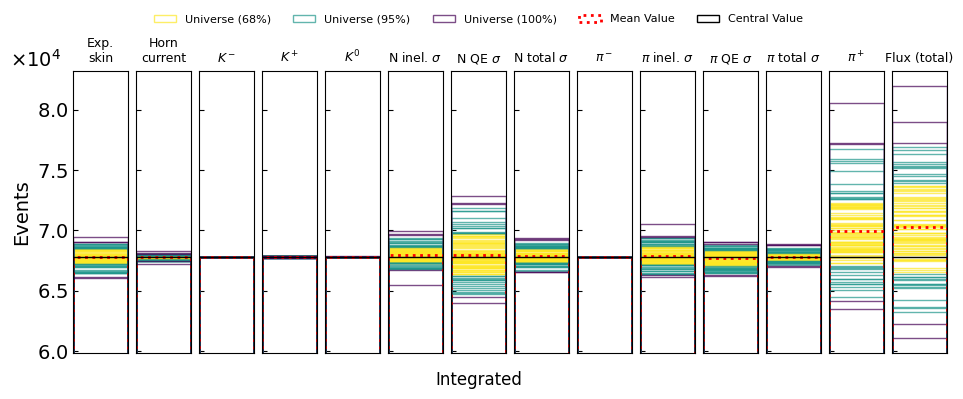

[15:29:29] saved /exp/sbnd/data/users/munjung/plots/numucc1p0pi/flux-asymmetry-20260519/flux-integrated-universes-side-by-side.png


In [28]:
n_panels = len(panel_specs)
panel_w = 0.675  # half of previous width (inches per thin subpanel)
fig_h = 3.6

# y limits from Flux (total) panel so asymmetry is visible
_, univ_tot_plot, cv_tot_plot = panel_specs[-1]
y_vals = np.concatenate([
    univ_tot_plot.ravel(),
    cv_tot_plot.ravel(),
    np.mean(univ_tot_plot, axis=0).ravel(),
])
y_lo, y_hi = float(np.min(y_vals)), float(np.max(y_vals))
y_pad = 0.06 * (y_hi - y_lo) if y_hi > y_lo else 0.02 * max(abs(y_hi), 1.0)
ylim = (y_lo - y_pad, y_hi + y_pad)

fig, axes = plt.subplots(
    1,
    n_panels,
    figsize=(panel_w * n_panels, fig_h),
    sharey=True,
    constrained_layout=True,
)
if n_panels == 1:
    axes = [axes]

legend_handles = None
legend_labels = None

for i, (ax, (label, univ, cv)) in enumerate(zip(axes, panel_specs)):
    plot_univ_hists_on_ax(
        ax,
        univ,
        cv,
        var_config,
        title=label,
        show_legend=(i == n_panels - 1),
    )
    ax.set_ylim(ylim)
    if i == n_panels - 1:
        legend_handles, legend_labels = ax.get_legend_handles_labels()
        ax.legend_.remove()  # use figure-level legend instead

axes[0].set_ylabel('Events')

# keep ×10^n clear of the first-panel title
_offset = axes[0].yaxis.get_offset_text()
_offset.set_x(-0.22)
_offset.set_ha('right')

fig.supxlabel('Integrated')
fig.legend(
    legend_handles,
    legend_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=5,
    frameon=False,
    fontsize=8,
)

# fig.suptitle('Flux systematic universes — integrated event rate', y=1.14, fontsize=11)
plt.savefig(SAVE_FIG + fig_ext, bbox_inches='tight', dpi=dpi)
plt.show()
_log('saved ' + SAVE_FIG + fig_ext)
